# 07 - CNNs

Este notebook ejecuta una batería de experimentos para comparar varias combinaciones:

```text
preprocesamiento × vectorización × estrategia de pesos de clase × CNN
```



## 1- Imports, intentamos ejecutar en GPU

In [29]:
import os
import re
import gc
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input,
    TextVectorization,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Concatenate,
    SpatialDropout1D,
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from gensim.models import Word2Vec, FastText

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs disponibles:', gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('GPU activada correctamente.')
    except RuntimeError as e:
        print('Aviso:', e)
else:
    print('No se ha detectado GPU. El notebook se ejecutará en CPU.')


TensorFlow: 2.20.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU activada correctamente.


## 2 - Cargamos los datos

In [30]:
CANDIDATE_PATHS = [
    '/content/dataset_preprocesado.csv',
    '/content/tcga_simple_train.csv',
    '/content/drive/MyDrive/PLN_data/dataset_preprocesado.csv',
    '/content/drive/MyDrive/PLN_data/tcga_simple_train.csv',
    '../Data/dataset_preprocesado.csv',
    '../Data/tcga_simple_train.csv',
]

DATA_PATH = None
for path in CANDIDATE_PATHS:
    if Path(path).exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        'No se ha encontrado el CSV. Sube el dataset a Colab o cambia DATA_PATH manualmente.'
    )

print('Cargando:', DATA_PATH)
df = pd.read_csv(DATA_PATH)

# Normalización mínima de columnas obligatorias
if 'text' not in df.columns or 't' not in df.columns:
    raise ValueError(f'El dataset debe contener columnas text y t. Columnas encontradas: {df.columns.tolist()}')

df = df.dropna(subset=['text', 't']).copy()
df['text'] = df['text'].astype(str)
df['t'] = df['t'].astype(str).str.upper().str.strip()

# Si no existe raw_text, la creamos para tener una baseline clara.
if 'raw_text' not in df.columns:
    df['raw_text'] = df['text']

print('Dimensiones:', df.shape)
display(df.head())
print(df['t'].value_counts())


Cargando: /content/dataset_preprocesado.csv
Dimensiones: (3968, 4)


,patient_id,text,t,raw_text
0,TCGA-BP-5195,date recelpt clinical diagnosis history incide...,T1,date recelpt clinical diagnosis history incide...
1,TCGA-D7-8573,material material stomach method collection le...,T3,material material stomach method collection le...
2,TCGA-EI-7004,page copy examination histopathological examin...,T4,page copy examination histopathological examin...
3,TCGA-EB-A82B,patient id gross description mass located righ...,T4,patient id gross description mass located righ...
4,TCGA-A6-3808,specimen right colon clinical notes pre op dia...,T3,specimen right colon clinical notes pre op dia...


t
T2    1353
T3    1209
T1     999
T4     407
Name: count, dtype: int64


In [31]:
# Columnas de texto a probar. Se seleccionan automáticamente solo las que existan.
PREFERRED_TEXT_COLUMNS = [
    'text',
    'raw_text',
    'prep_0_base',
    'prep_1_lower',
    'prep_2_lemma',
    'prep_3_pos',
    'prep_4_lemma_pos',
]

TEXT_COLUMNS = [col for col in PREFERRED_TEXT_COLUMNS if col in df.columns]
print('Columnas de texto que se probarán:', TEXT_COLUMNS)

# Modos de vectorización para CNN secuencial.
# trainable_embedding: la red aprende sus propios embeddings.
# word2vec: inicialización con Word2Vec entrenado sobre el train.
# fasttext: inicialización con FastText entrenado sobre el train.
SEQUENTIAL_VECTORIZERS = [
    'trainable_embedding',
    'word2vec',
    'fasttext',
]


SPARSE_VECTORIZERS = [
    'bow_binary',
    'bow_counts',
    'tfidf_word',
    'tfidf_char',
]

RUN_SPARSE_VECTORIZERS = True


CLASS_WEIGHT_MODES = ['none', 'soft']
# CLASS_WEIGHT_MODES = ['none', 'soft', 'balanced']

# Hiperparámetros generales
MAX_TOKENS = 40000
SEQ_LEN = 800
EMBEDDING_DIM = 128
MAX_SPARSE_FEATURES = 15000

BATCH_SIZE = 64
EPOCHS = 15
PATIENCE = 4

RESULTS_DIR = Path('/content/Results/Metrics')
MODELS_DIR = Path('/content/Models')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_PATH = RESULTS_DIR / 'cnn_grid_results.csv'
BEST_MODEL_PATH = MODELS_DIR / 'best_cnn_grid.keras'
BEST_CONFIG_PATH = MODELS_DIR / 'best_cnn_grid_config.json'

print('Resultados en:', RESULTS_PATH)
print('Mejor modelo en:', BEST_MODEL_PATH)


Columnas de texto que se probarán: ['text', 'raw_text']
Resultados en: /content/Results/Metrics/cnn_grid_results.csv
Mejor modelo en: /content/Models/best_cnn_grid.keras


## 3 - Split train/validation y codificación de etiquetas

In [32]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df['t']
)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df['t'])
y_val = label_encoder.transform(val_df['t'])

num_classes = len(label_encoder.classes_)
print('Clases:', label_encoder.classes_)
print('Train:', train_df.shape)
print('Validation:', val_df.shape)


Clases: ['T1' 'T2' 'T3' 'T4']
Train: (3174, 4)
Validation: (794, 4)


## 4 - Ajuste de pesos

In [ ]:
def get_class_weight_dict(mode, y):
    if mode == 'none':
        return None

    weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y),
        y=y
    )

    if mode == 'soft':
        weights = np.sqrt(weights)

    return {i: float(w) for i, w in enumerate(weights)}


class F1Callback(Callback):
    def __init__(self, validation_data):
        super().__init__()
        self.X_val, self.y_val = validation_data
        self.val_f1_macro = []
        self.val_f1_weighted = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        y_pred_probs = self.model.predict(self.X_val, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)

        f1_macro = f1_score(self.y_val, y_pred, average='macro')
        f1_weighted = f1_score(self.y_val, y_pred, average='weighted')

        self.val_f1_macro.append(f1_macro)
        self.val_f1_weighted.append(f1_weighted)

        logs['val_f1_macro'] = f1_macro
        logs['val_f1_weighted'] = f1_weighted

        print(f' — val_f1_macro: {f1_macro:.4f} — val_f1_weighted: {f1_weighted:.4f}')


def safe_name(text):
    text = re.sub(r'[^a-zA-Z0-9_\-]+', '_', text)
    return text.strip('_')


def save_results(results):
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('macro_f1', ascending=False)
    results_df.to_csv(RESULTS_PATH, index=False)
    return results_df


## 5 - Utilidades pra embeddings estáticos secuenciales

In [34]:
def simple_tokenize(text):
    return str(text).split()


def train_static_embedding_model(texts, mode, vector_size=128, min_count=2, workers=2, epochs=8):
    tokenized = [simple_tokenize(t) for t in texts]

    if mode == 'word2vec':
        model = Word2Vec(
            sentences=tokenized,
            vector_size=vector_size,
            window=5,
            min_count=min_count,
            workers=workers,
            sg=1,
            epochs=epochs,
            seed=SEED,
        )
    elif mode == 'fasttext':
        model = FastText(
            sentences=tokenized,
            vector_size=vector_size,
            window=5,
            min_count=min_count,
            workers=workers,
            sg=1,
            epochs=epochs,
            seed=SEED,
        )
    else:
        raise ValueError(f'Modo de embeddings no válido: {mode}')

    return model


def build_embedding_matrix(vectorizer, static_model, embedding_dim):
    vocab = vectorizer.get_vocabulary()
    matrix = np.random.normal(0, 0.05, size=(len(vocab), embedding_dim)).astype('float32')

    # Índice 0 = padding para TextVectorization
    if len(vocab) > 0:
        matrix[0] = np.zeros(embedding_dim, dtype='float32')

    found = 0
    for i, token in enumerate(vocab):
        if token in static_model.wv:
            matrix[i] = static_model.wv[token]
            found += 1

    coverage = found / max(len(vocab), 1)
    return matrix, coverage


## 6 - Configuramos la CNN

In [35]:
def build_sequence_cnn(vectorizer, num_classes, embedding_matrix=None, embedding_trainable=True):
    inputs = Input(shape=(1,), dtype=tf.string)
    x = vectorizer(inputs)

    vocab_size = len(vectorizer.get_vocabulary())

    if embedding_matrix is None:
        x = Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            mask_zero=False,
            name='embedding_trainable'
        )(x)
    else:
        x = Embedding(
            input_dim=embedding_matrix.shape[0],
            output_dim=embedding_matrix.shape[1],
            weights=[embedding_matrix],
            trainable=embedding_trainable,
            mask_zero=False,
            name='embedding_static'
        )(x)

    x = SpatialDropout1D(0.2)(x)

    convs = []
    for kernel_size in [3, 5, 7]:
        conv = Conv1D(
            filters=128,
            kernel_size=kernel_size,
            activation='relu',
            padding='same'
        )(x)
        pool = GlobalMaxPooling1D()(conv)
        convs.append(pool)

    x = Concatenate()(convs)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=2e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_sparse_cnn(input_length, num_classes):
    inputs = Input(shape=(input_length, 1), dtype=tf.float32)

    x = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same')(inputs)
    x = GlobalMaxPooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=2e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


## 7 - Funciones de vectorización para cada experimento

In [36]:
def prepare_sequence_inputs(text_col, vectorizer_mode):
    X_train_text = train_df[text_col].fillna('').astype(str).values
    X_val_text = val_df[text_col].fillna('').astype(str).values

    vectorizer = TextVectorization(
        max_tokens=MAX_TOKENS,
        output_mode='int',
        output_sequence_length=SEQ_LEN,
        standardize='lower_and_strip_punctuation'
    )
    vectorizer.adapt(X_train_text)

    embedding_matrix = None
    coverage = None

    if vectorizer_mode in ['word2vec', 'fasttext']:
        print(f'Entrenando {vectorizer_mode} para {text_col}...')
        static_model = train_static_embedding_model(
            X_train_text,
            mode=vectorizer_mode,
            vector_size=EMBEDDING_DIM,
            min_count=2,
            workers=2,
            epochs=8
        )
        embedding_matrix, coverage = build_embedding_matrix(vectorizer, static_model, EMBEDDING_DIM)
        print(f'Cobertura de vocabulario con {vectorizer_mode}: {coverage:.4f}')

    return X_train_text, X_val_text, vectorizer, embedding_matrix, coverage


def prepare_sparse_inputs(text_col, vectorizer_mode):
    X_train_text = train_df[text_col].fillna('').astype(str).values
    X_val_text = val_df[text_col].fillna('').astype(str).values

    if vectorizer_mode == 'bow_binary':
        vec = CountVectorizer(
            binary=True,
            ngram_range=(1, 2),
            min_df=2,
            max_features=MAX_SPARSE_FEATURES
        )
    elif vectorizer_mode == 'bow_counts':
        vec = CountVectorizer(
            binary=False,
            ngram_range=(1, 2),
            min_df=2,
            max_features=MAX_SPARSE_FEATURES
        )
    elif vectorizer_mode == 'tfidf_word':
        vec = TfidfVectorizer(
            analyzer='word',
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True,
            max_features=MAX_SPARSE_FEATURES
        )
    elif vectorizer_mode == 'tfidf_char':
        vec = TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True,
            max_features=MAX_SPARSE_FEATURES
        )
    else:
        raise ValueError(f'Vectorizador disperso no válido: {vectorizer_mode}')

    X_train_sparse = vec.fit_transform(X_train_text)
    X_val_sparse = vec.transform(X_val_text)

    # Para pasarlo a Conv1D convertimos a denso y añadimos canal final.
    X_train_arr = X_train_sparse.toarray().astype('float32')[..., np.newaxis]
    X_val_arr = X_val_sparse.toarray().astype('float32')[..., np.newaxis]

    return X_train_arr, X_val_arr, vec


## 8 - Entrenamiento de un único experimento

In [37]:
def train_one_experiment(text_col, vectorizer_mode, class_weight_mode, input_family):
    K.clear_session()
    gc.collect()

    experiment_name = f"{input_family}__{text_col}__{vectorizer_mode}__cw_{class_weight_mode}"

    print("\n" + "=" * 100)
    print("Experimento:", experiment_name)
    print("=" * 100)

    class_weight = get_class_weight_dict(class_weight_mode, y_train)
    coverage = None

    if input_family == "sequence":
        X_train_input, X_val_input, vectorizer, embedding_matrix, coverage = prepare_sequence_inputs(
            text_col,
            vectorizer_mode
        )

        model = build_sequence_cnn(
            vectorizer=vectorizer,
            num_classes=num_classes,
            embedding_matrix=embedding_matrix,
            embedding_trainable=True
        )

    elif input_family == "sparse":
        X_train_input, X_val_input, sparse_vectorizer = prepare_sparse_inputs(
            text_col,
            vectorizer_mode
        )

        model = build_sparse_cnn(
            input_length=X_train_input.shape[1],
            num_classes=num_classes
        )

    else:
        raise ValueError(f"input_family no válido: {input_family}")

    f1_callback = F1Callback(validation_data=(X_val_input, y_val))

    early_stop = EarlyStopping(
        monitor="val_f1_macro",
        mode="max",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_f1_macro",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )

    history = model.fit(
        X_train_input,
        y_train,
        validation_data=(X_val_input, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight,
        callbacks=[f1_callback, reduce_lr, early_stop],
        verbose=1
    )

    y_pred_probs = model.predict(X_val_input, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    macro_f1 = f1_score(y_val, y_pred, average="macro")
    weighted_f1 = f1_score(y_val, y_pred, average="weighted")
    accuracy = np.mean(y_pred == y_val)

    result = {
        "experiment": experiment_name,
        "input_family": input_family,
        "text_column": text_col,
        "vectorizer": vectorizer_mode,
        "class_weight_mode": class_weight_mode,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "accuracy": accuracy,
        "best_val_f1_macro_during_training": max(f1_callback.val_f1_macro) if f1_callback.val_f1_macro else None,
        "embedding_coverage": coverage,
        "epochs_trained": len(history.history["loss"])
    }

    print("Resultado:", result)

    return model, result, y_pred, history

## 9 - Ejecutamos todas las combinaciones de experimentos


In [38]:
results = []
completed_experiments = set()

if RESULTS_PATH.exists():
    previous_results = pd.read_csv(RESULTS_PATH)
    results = previous_results.to_dict('records')
    completed_experiments = set(previous_results['experiment'].tolist())
    print(f'Se han cargado {len(results)} resultados previos.')

best_macro_f1 = max([r['macro_f1'] for r in results], default=-1)
best_config = None
best_y_pred = None
best_history = None

for text_col in TEXT_COLUMNS:
    for vectorizer_mode in SEQUENTIAL_VECTORIZERS:
        for class_weight_mode in CLASS_WEIGHT_MODES:

            experiment_name = f'sequence__{text_col}__{vectorizer_mode}__cw_{class_weight_mode}'
            if experiment_name in completed_experiments:
                print('Saltando experimento ya completado:', experiment_name)
                continue

            model, result, y_pred, history = train_one_experiment(
                text_col=text_col,
                vectorizer_mode=vectorizer_mode,
                class_weight_mode=class_weight_mode,
                input_family='sequence'
            )

            results.append(result)
            results_df = save_results(results)
            completed_experiments.add(experiment_name)

            if result['macro_f1'] > best_macro_f1:
                best_macro_f1 = result['macro_f1']
                best_config = result
                best_y_pred = y_pred
                best_history = history
                model.save(BEST_MODEL_PATH)
                with open(BEST_CONFIG_PATH, 'w', encoding='utf-8') as f:
                    json.dump(best_config, f, indent=4)
                print('Nuevo mejor modelo guardado:', BEST_MODEL_PATH)

            del model
            gc.collect()
            K.clear_session()

if RUN_SPARSE_VECTORIZERS:
    for text_col in TEXT_COLUMNS:
        for vectorizer_mode in SPARSE_VECTORIZERS:
            for class_weight_mode in CLASS_WEIGHT_MODES:

                experiment_name = f'sparse__{text_col}__{vectorizer_mode}__cw_{class_weight_mode}'
                if experiment_name in completed_experiments:
                    print('Saltando experimento ya completado:', experiment_name)
                    continue

                model, result, y_pred, history = train_one_experiment(
                    text_col=text_col,
                    vectorizer_mode=vectorizer_mode,
                    class_weight_mode=class_weight_mode,
                    input_family='sparse'
                )

                results.append(result)
                results_df = save_results(results)
                completed_experiments.add(experiment_name)

                if result['macro_f1'] > best_macro_f1:
                    best_macro_f1 = result['macro_f1']
                    best_config = result
                    best_y_pred = y_pred
                    best_history = history
                    model.save(BEST_MODEL_PATH)
                    with open(BEST_CONFIG_PATH, 'w', encoding='utf-8') as f:
                        json.dump(best_config, f, indent=4)
                    print('Nuevo mejor modelo guardado:', BEST_MODEL_PATH)

                del model
                gc.collect()
                K.clear_session()

results_df = save_results(results)
display(results_df.head(20))
print('Mejor macro F1:', results_df.iloc[0]['macro_f1'])
print('Mejor experimento:', results_df.iloc[0]['experiment'])



Experimento: sequence__text__trainable_embedding__cw_none
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.3069 - loss: 1.3540 — val_f1_macro: 0.1272 — val_f1_weighted: 0.1737
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.3318 - loss: 1.3361 - val_accuracy: 0.3413 - val_loss: 1.3073 - val_f1_macro: 0.1272 - val_f1_weighted: 0.1737 - learning_rate: 2.0000e-04
Epoch 2/15
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3339 - loss: 1.3104 — val_f1_macro: 0.1272 — val_f1_weighted: 0.1737
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.3327 - loss: 1.3111 - val_accuracy: 0.3413 - val_loss: 1.3012 - val_f1_macro: 0.1272 - val_f1_weighted: 0.1737 - learning_rate: 2.0000e-04
Epoch 3/15
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3397 - loss: 1.3126 — val_f1_macro: 0.1272 — val_f1_weighted: 0.1737

Epoch 3: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.3425 - loss: 1.3116 -

Cobertura de vocabulario con fasttext: 1.0000
Epoch 1/15
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2885 - loss: 1.6002 — val_f1_macro: 0.1694 — val_f1_weighted: 0.2245
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.3021 - loss: 1.4383 - val_accuracy: 0.3426 - val_loss: 1.3079 - val_f1_macro: 0.1694 - val_f1_weighted: 0.2245 - learning_rate: 2.0000e-04
Epoch 2/15
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3266 - loss: 1.3310 — val_f1_macro: 0.2201 — val_f1_weighted: 0.2732
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.3327 - loss: 1.3263 - val_accuracy: 0.3804 - val_loss: 1.2781 - val_f1_macro: 0.2201 - val_f1_weighted: 0.2732 - learning_rate: 2.0000e-04
Epoch 3/15
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3409 - loss: 1.3095 — val_f1_macro: 0.3654 — val_f1_weighted: 0.4413
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.3648 - loss: 1.2991 - val_accuracy: 0.4748 - val_loss: 1.2452 - val_f1_macro: 0.3654 - val_f1_weighted: 0.4413 -

Cobertura de vocabulario con fasttext: 1.0000
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2998 - loss: 1.4853 — val_f1_macro: 0.2809 — val_f1_weighted: 0.3269
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.3173 - loss: 1.4053 - val_accuracy: 0.3829 - val_loss: 1.3254 - val_f1_macro: 0.2809 - val_f1_weighted: 0.3269 - learning_rate: 2.0000e-04
Epoch 2/15
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3525 - loss: 1.3323 — val_f1_macro: 0.3414 — val_f1_weighted: 0.4002
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.3551 - loss: 1.3210 - val_accuracy: 0.4332 - val_loss: 1.3114 - val_f1_macro: 0.3414 - val_f1_weighted: 0.4002 - learning_rate: 2.0000e-04
Epoch 3/15
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3675 - loss: 1.2994 — val_f1_macro: 0.4192 — val_f1_weighted: 0.4497
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.3834 - loss: 1.2863 - val_accuracy: 0.4584 - val_loss: 1.2681 - val_f1_macro: 0.4192 - val_f1_weighted: 0.4497 -

Cobertura de vocabulario con fasttext: 1.0000
Epoch 1/15
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2815 - loss: 1.6539 — val_f1_macro: 0.1399 — val_f1_weighted: 0.1875
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.3066 - loss: 1.4651 - val_accuracy: 0.3438 - val_loss: 1.3052 - val_f1_macro: 0.1399 - val_f1_weighted: 0.1875 - learning_rate: 2.0000e-04
Epoch 2/15
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3510 - loss: 1.3075 — val_f1_macro: 0.3459 — val_f1_weighted: 0.4170
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.3538 - loss: 1.3043 - val_accuracy: 0.4559 - val_loss: 1.2653 - val_f1_macro: 0.3459 - val_f1_weighted: 0.4170 - learning_rate: 2.0000e-04
Epoch 3/15
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3771 - loss: 1.2902 — val_f1_macro: 0.3757 — val_f1_weighted: 0.4526
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.3825 - loss: 1.2833 - val_accuracy: 0.4849 - val_loss: 1.2411 - val_f1_macro: 0.3757 - val_f1_weighted: 0.4526 -

Cobertura de vocabulario con fasttext: 1.0000
Epoch 1/15
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3019 - loss: 1.5922 — val_f1_macro: 0.3149 — val_f1_weighted: 0.3850
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.3103 - loss: 1.4768 - val_accuracy: 0.4232 - val_loss: 1.3361 - val_f1_macro: 0.3149 - val_f1_weighted: 0.3850 - learning_rate: 2.0000e-04
Epoch 2/15
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3369 - loss: 1.3284 — val_f1_macro: 0.2647 — val_f1_weighted: 0.3354
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.3425 - loss: 1.3306 - val_accuracy: 0.4043 - val_loss: 1.3034 - val_f1_macro: 0.2647 - val_f1_weighted: 0.3354 - learning_rate: 2.0000e-04
Epoch 3/15
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3670 - loss: 1.3143 — val_f1_macro: 0.3260 — val_f1_weighted: 0.3869
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.3790 - loss: 1.3105 - val_accuracy: 0.4244 - val_loss: 1.2723 - val_f1_macro: 0.3260 - val_f1_weighted: 0.3869 -

,experiment,input_family,text_column,vectorizer,class_weight_mode,macro_f1,weighted_f1,accuracy,best_val_f1_macro_during_training,embedding_coverage,epochs_trained
7,sequence__raw_text__trainable_embedding__cw_soft,sequence,raw_text,trainable_embedding,soft,0.753611,0.771050,0.769521,0.753611,NaN,15
1,sequence__text__trainable_embedding__cw_soft,sequence,text,trainable_embedding,soft,0.751951,0.772285,0.770781,0.751951,NaN,15
4,sequence__text__fasttext__cw_none,sequence,text,fasttext,none,0.632566,0.666840,0.671285,0.632566,1.000000,15
10,sequence__raw_text__fasttext__cw_none,sequence,raw_text,fasttext,none,0.627650,0.660238,0.662469,0.627650,1.000000,15
11,sequence__raw_text__fasttext__cw_soft,sequence,raw_text,fasttext,soft,0.603784,0.622882,0.622166,0.603784,1.000000,15
2,sequence__text__word2vec__cw_none,sequence,text,word2vec,none,0.603509,0.640286,0.646096,0.603509,0.460842,15
5,sequence__text__fasttext__cw_soft,sequence,text,fasttext,soft,0.597710,0.617597,0.620907,0.597710,1.000000,15
3,sequence__text__word2vec__cw_soft,sequence,text,word2vec,soft,0.591989,0.607233,0.610831,0.591989,0.460842,15
8,sequence__raw_text__word2vec__cw_none,sequence,raw_text,word2vec,none,0.587676,0.614186,0.615869,0.587676,0.460842,15
9,sequence__raw_text__word2vec__cw_soft,sequence,raw_text,word2vec,soft,0.564888,0.576080,0.579345,0.564888,0.460842,15


Mejor macro F1: 0.753611340608915
Mejor experimento: sequence__raw_text__trainable_embedding__cw_soft


## 10 - Visualización de los mejores experimentos

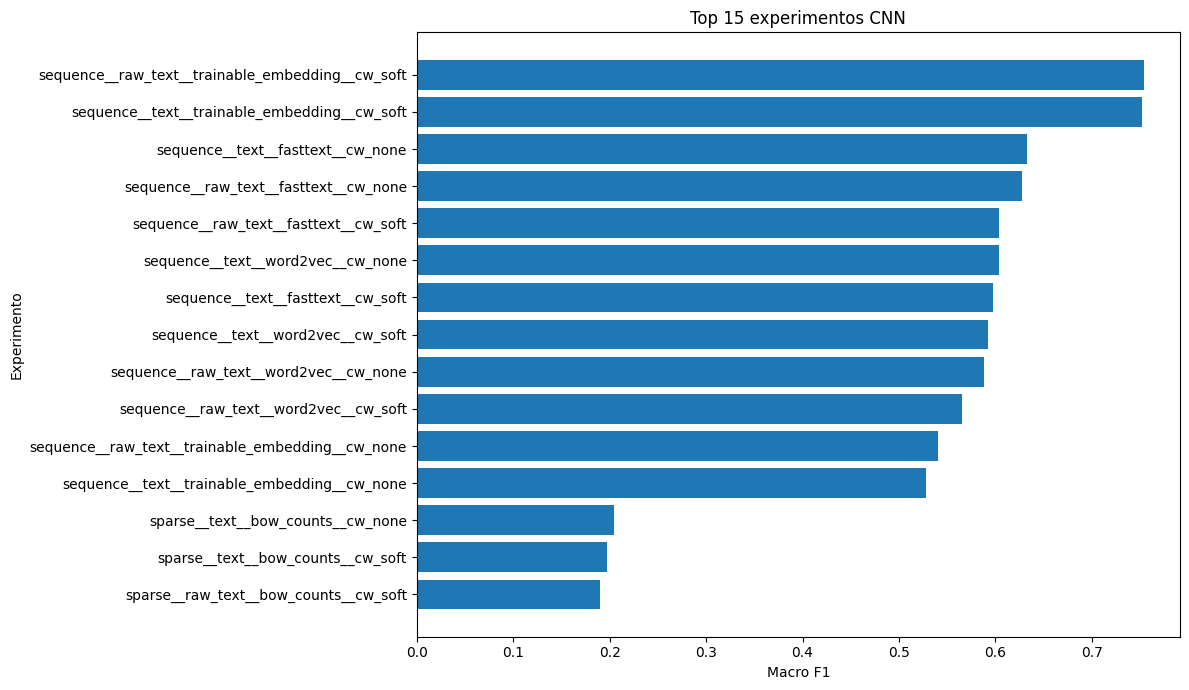

,experiment,input_family,text_column,vectorizer,class_weight_mode,macro_f1,weighted_f1,accuracy,best_val_f1_macro_during_training,embedding_coverage,epochs_trained
0,sequence__raw_text__trainable_embedding__cw_soft,sequence,raw_text,trainable_embedding,soft,0.753611,0.771050,0.769521,0.753611,NaN,15
1,sequence__text__trainable_embedding__cw_soft,sequence,text,trainable_embedding,soft,0.751951,0.772285,0.770781,0.751951,NaN,15
2,sequence__text__fasttext__cw_none,sequence,text,fasttext,none,0.632566,0.666840,0.671285,0.632566,1.000000,15
3,sequence__raw_text__fasttext__cw_none,sequence,raw_text,fasttext,none,0.627650,0.660238,0.662469,0.627650,1.000000,15
4,sequence__raw_text__fasttext__cw_soft,sequence,raw_text,fasttext,soft,0.603784,0.622882,0.622166,0.603784,1.000000,15
5,sequence__text__word2vec__cw_none,sequence,text,word2vec,none,0.603509,0.640286,0.646096,0.603509,0.460842,15
6,sequence__text__fasttext__cw_soft,sequence,text,fasttext,soft,0.597710,0.617597,0.620907,0.597710,1.000000,15
7,sequence__text__word2vec__cw_soft,sequence,text,word2vec,soft,0.591989,0.607233,0.610831,0.591989,0.460842,15
8,sequence__raw_text__word2vec__cw_none,sequence,raw_text,word2vec,none,0.587676,0.614186,0.615869,0.587676,0.460842,15
9,sequence__raw_text__word2vec__cw_soft,sequence,raw_text,word2vec,soft,0.564888,0.576080,0.579345,0.564888,0.460842,15


In [39]:
results_df = pd.read_csv(RESULTS_PATH).sort_values('macro_f1', ascending=False)

top = results_df.head(15).copy()

plt.figure(figsize=(12, 7))
plt.barh(top['experiment'], top['macro_f1'])
plt.xlabel('Macro F1')
plt.ylabel('Experimento')
plt.title('Top 15 experimentos CNN')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(top)


## 11- Matriz de confusión del mejor experimento

Mejor configuración:
{'experiment': 'sequence__raw_text__trainable_embedding__cw_soft', 'input_family': 'sequence', 'text_column': 'raw_text', 'vectorizer': 'trainable_embedding', 'class_weight_mode': 'soft', 'macro_f1': 0.753611340608915, 'weighted_f1': 0.7710504154117674, 'accuracy': 0.7695214105793451, 'best_val_f1_macro_during_training': 0.753611340608915, 'embedding_coverage': nan, 'epochs_trained': 15}

Experimento: sequence__raw_text__trainable_embedding__cw_soft
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.2690 - loss: 1.3517 — val_f1_macro: 0.1272 — val_f1_weighted: 0.1737
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - accuracy: 0.2839 - loss: 1.3445 - val_accuracy: 0.3413 - val_loss: 1.3328 - val_f1_macro: 0.1272 - val_f1_weighted: 0.1737 - learning_rate: 2.0000e-04
Epoch 2/15
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3256 - loss: 1.3325 — val_f1_macro: 0.1272 — val_f1_weighted: 0.1737
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.3311 - l

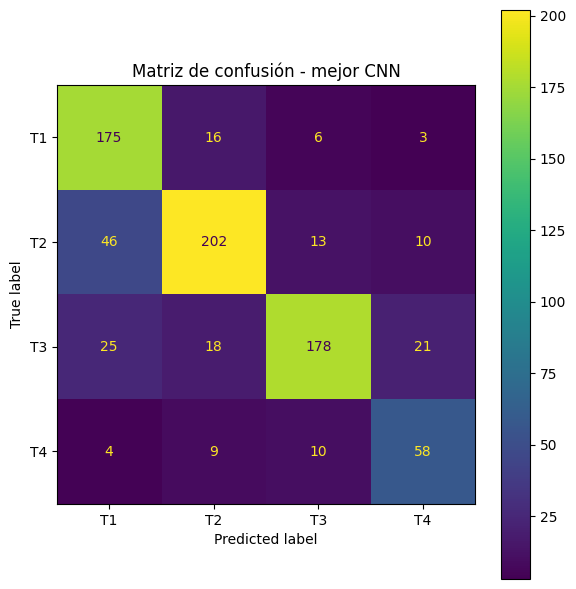

Mejor modelo guardado en: /content/Models/best_cnn_grid.keras


In [40]:
best_row = results_df.iloc[0].to_dict()
print('Mejor configuración:')
print(best_row)

best_model, best_result, y_pred_best, best_history = train_one_experiment(
    text_col=best_row['text_column'],
    vectorizer_mode=best_row['vectorizer'],
    class_weight_mode=best_row['class_weight_mode'],
    input_family=best_row['input_family']
)

print(classification_report(
    y_val,
    y_pred_best,
    target_names=label_encoder.classes_
))

cm = confusion_matrix(y_val, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)
plt.title('Matriz de confusión - mejor CNN')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cnn_best_confusion_matrix.png', dpi=300)
plt.show()

best_model.save(BEST_MODEL_PATH)
with open(BEST_CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(best_row, f, indent=4)

print('Mejor modelo guardado en:', BEST_MODEL_PATH)


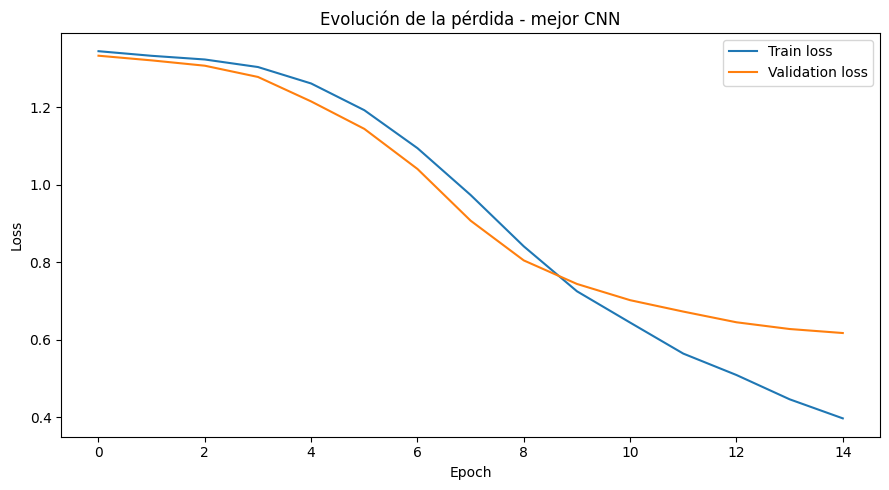

In [41]:
# ============================================================
# 14. Curvas de entrenamiento del mejor experimento
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(best_history.history['loss'], label='Train loss')
plt.plot(best_history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Evolución de la pérdida - mejor CNN')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cnn_best_loss_curve.png', dpi=300)
plt.show()

if hasattr(best_history, 'history'):
    # El F1 lo guardamos en el callback, no en history siempre.
    pass
